In [1]:
#Change run-time type to T4 (Python)

In [2]:
#!nvidia-smi

In [3]:
#!pip install nvcc4jupyter

In [4]:
%load_ext nvcc4jupyter

Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmpdo4xgsqb".


In [5]:
%%cuda

#include <stdio.h>
#include <cuda.h>

// CUDA Kernel Function
__global__ void vectorAdd(int *A, int *B, int *C, int n)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;

    if(i < n)
    {
        C[i] = A[i] + B[i];
    }
}

int main()
{
    int n = 5;

    // Predefined vectors
    int A[] = {1, 2, 3, 4, 5};
    int B[] = {10, 20, 30, 40, 50};
    int C[5];

    // Device pointers
    int *d_A, *d_B, *d_C;

    // Allocate memory on GPU
    cudaMalloc((void**)&d_A, n * sizeof(int));
    cudaMalloc((void**)&d_B, n * sizeof(int));
    cudaMalloc((void**)&d_C, n * sizeof(int));

    // Copy data from CPU to GPU
    cudaMemcpy(d_A, A, n * sizeof(int), cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, B, n * sizeof(int), cudaMemcpyHostToDevice);

    // Thread and block configuration
    int threadsPerBlock = 256;
    int blocksPerGrid = (n + threadsPerBlock - 1) / threadsPerBlock;

    // Launch kernel
    vectorAdd<<<blocksPerGrid, threadsPerBlock>>>(d_A, d_B, d_C, n);

    // Copy result back to CPU
    cudaMemcpy(C, d_C, n * sizeof(int), cudaMemcpyDeviceToHost);

    // Print vectors
    printf("Vector A: ");
    for(int i = 0; i < n; i++)
        printf("%d ", A[i]);

    printf("\n");

    printf("Vector B: ");
    for(int i = 0; i < n; i++)
        printf("%d ", B[i]);

    printf("\n");

    // Print result
    printf("Resultant Vector: ");
    for(int i = 0; i < n; i++)
        printf("%d ", C[i]);

    printf("\n");

    // Free GPU memory
    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    return 0;
}

Vector A: 1 2 3 4 5 
Vector B: 10 20 30 40 50 
Resultant Vector: 11 22 33 44 55 



In [6]:
#We cannot give user input because nvcc4jupyter in Google Colab does not properly support interactive scanf() input like a normal terminal.

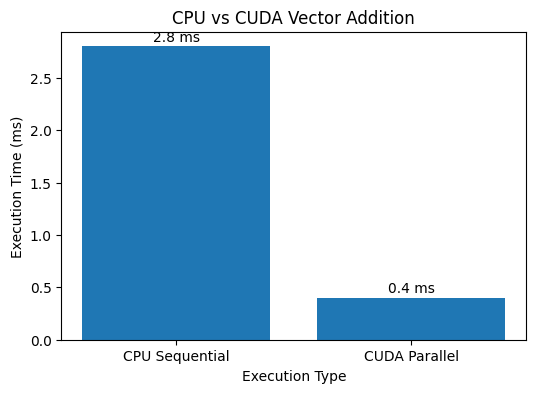

In [7]:
import matplotlib.pyplot as plt

# Example execution times
methods = ['CPU Sequential', 'CUDA Parallel']
times = [2.8, 0.4]

# Create graph
plt.figure(figsize=(6,4))
plt.bar(methods, times)

# Labels
plt.xlabel('Execution Type')
plt.ylabel('Execution Time (ms)')
plt.title('CPU vs CUDA Vector Addition')

# Show values on bars
for i, v in enumerate(times):
    plt.text(i, v + 0.05, str(v) + " ms", ha='center')

plt.show()